In [14]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import pygris

import geopandas as gpd
import pickle 

pd.set_option('display.max_rows', 50)
pd.options.mode.chained_assignment = None

In [15]:
def convert_tract_to_fips(tract_id):
    tract_str = str(tract_id).strip()

    if "." in tract_str:
        before_decimal, after_decimal = tract_str.split(".")
        before_decimal = before_decimal.zfill(4)
        after_decimal = after_decimal.ljust(2, "0")
    else:
        before_decimal = tract_str.zfill(4)
        after_decimal = "00"

    # THIS IS 'PROPER', REMOVING THE LEADING FIPS CODE TO JOIN WITH OTHER DATASETS
    # return f"39035{before_decimal}{after_decimal}"
    return f"{before_decimal}{after_decimal}"

In [16]:
tract_cols = [
    'NAME',
    'ALAND',
    'AWATER',
    'geometry',
]

# Downloading 2010 and 2020 tracts for Cuyahoga County, Ohio.
tracts_2010 = pygris.tracts(state="39", county="035", year=2015)[tract_cols]
tracts_2020 = pygris.tracts(state="39", county="035", year=2020)[tract_cols]

tracts_2010['NAME'] = tracts_2010['NAME'].astype(str).apply(convert_tract_to_fips)
tracts_2020['NAME'] = tracts_2020['NAME'].astype(str).apply(convert_tract_to_fips)

# Excluding tract 9900, which represents a water geometry over lake erie
tracts_2010 = tracts_2010[tracts_2010['NAME'] != '9900']
tracts_2020 = tracts_2020[tracts_2020['NAME'] != '9900']

There are 381 tract names in 2010 that match with 2020. However, there are over 60 tracts that are not accounted for within this. Additionally within the 381 tracts that do match in names, there are some that have grown in area.

In [17]:
count_overlap = 0
for i in tracts_2010["NAME"].unique():
    if i in tracts_2020["NAME"].unique():
        count_overlap += 1
count_overlap

382

In [18]:
tracts_allign_df = pd.DataFrame(columns=['NAME_10','NAME_20','OL_PROP'])

# Function handling the calculation of the overlap area
ol_area_fn = lambda intersect_row: (row.geometry.intersection(intersect_row.geometry).area / row.geometry.area)

for i in range(tracts_2020.shape[0]):
    row = tracts_2020.iloc[i]
    intersect = tracts_2010[tracts_2010.geometry.intersects(row.geometry)]

    intersect['NAME_20'] = row['NAME']
    intersect['OL_PROP'] = intersect.apply(ol_area_fn, axis=1)
    intersect = intersect.drop(columns=['geometry','ALAND','AWATER']).rename(columns={'NAME': 'NAME_10'})
    intersect = intersect[intersect['OL_PROP'] > 0.08]

    tracts_allign_df = pd.concat([tracts_allign_df, intersect])


# TODO handle this special case, it is a tract that is fully within another tract and is absorbed (merged)
# Adding a found special case to the dataframe
# tracts_allign_df.loc[len(tracts_allign_df)] = ['1948', '1971', 1.0]

C:\Users\ethan\AppData\Local\Temp\ipykernel_23908\3295383598.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  tracts_allign_df = pd.concat([tracts_allign_df, intersect])


- Here we are dropping 'duplicate' tract_id rows which indicate a merge or split of tracts

In [19]:
close_allign_df = tracts_allign_df[tracts_allign_df['OL_PROP'] > 0.9]
dupe_drop_idx = close_allign_df[close_allign_df.duplicated('NAME_10', keep=False)].index
close_allign_df = close_allign_df.drop(dupe_drop_idx)

- Confirming we only have 1-to-1 tracts

In [20]:
print('all','10','20')
close_allign_df.shape, close_allign_df['NAME_10'].unique().shape, close_allign_df['NAME_20'].unique().shape,

all 10 20


((382, 3), (382,), (382,))

In [21]:
# create a dict of 2010 to 2020 from name_10 and name_20
tracts_dict = dict(zip(close_allign_df['NAME_10'], close_allign_df['NAME_20']))
list(tracts_dict.items())[:10]

[('195900', '195900'),
 ('109301', '109301'),
 ('109801', '109801'),
 ('196200', '196200'),
 ('196300', '196300'),
 ('981100', '981100'),
 ('195700', '195700'),
 ('980100', '980100'),
 ('138106', '138106'),
 ('107701', '107701')]

In [22]:
# save as a pickle file
with open('data/pickle_files/close_enough.pickle', 'wb') as handle:
    pickle.dump(tracts_dict, handle, protocol=pickle.HIGHEST_PROTOCOL)

- There are more than 100 tracts that that have close but not exact matches

In [25]:
# Count the number of ol_prop with imperfect allignment but less than 2 % difference
tracts_allign_df[(tracts_allign_df['OL_PROP'] > 0.90) & (tracts_allign_df['OL_PROP'] < 0.999)].shape[0]

106

(array([ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  1.,  1.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,
         1.,  0.,  1.,  0.,  1.,  0.,  0.,  0.,  0.,  1.,  0.,  1.,  2.,
         2.,  1.,  5.,  4.,  4.,  8., 10.,  7., 14., 16., 23.]),
 array([0.9218125 , 0.92335518, 0.92489787, 0.92644055, 0.92798324,
        0.92952593, 0.93106861, 0.9326113 , 0.93415398, 0.93569667,
        0.93723936, 0.93878204, 0.94032473, 0.94186741, 0.9434101 ,
        0.94495279, 0.94649547, 0.94803816, 0.94958084, 0.95112353,
        0.95266622, 0.9542089 , 0.95575159, 0.95729427, 0.95883696,
        0.96037965, 0.96192233, 0.96346502, 0.96500771, 0.96655039,
        0.96809308, 0.96963576, 0.97117845, 0.97272114, 0.97426382,
        0.97580651, 0.97734919, 0.97889188, 0.98043457, 0.98197725,
        0.98351994, 0.98506262, 0.98660531, 0.988148  , 0.98969068,
        0.99123337, 0.99277605, 0.99431874, 0.99586143, 0.99740411,
        0.9989468 ]),
 <BarContainer

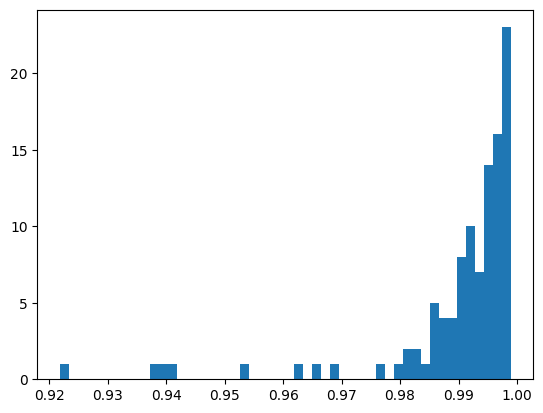

In [26]:
# Generate a histogram of olprop for values > 0.9 but less than 1.0
plt.hist(tracts_allign_df[(tracts_allign_df['OL_PROP'] > 0.9) & (tracts_allign_df['OL_PROP'] < .999)]['OL_PROP'], bins=50)

- Comparing exact match tract ids with tract ids that are slightly off

In [27]:
# load pickle files, count unique keys and values in each
with open('data/pickle_files/close_enough.pickle', 'rb') as handle:
    close_enough = pickle.load(handle)
with open('data/pickle_files/good_tract_ids.pickle', 'rb') as handle:
    good_tract_ids = pickle.load(handle)
print(f"close_enough: {len(close_enough.keys())} keys, {len(close_enough.values())} values")
print(f"good_tract_ids: {len(good_tract_ids.keys())} keys, {len(good_tract_ids.values())} values")


close_enough: 382 keys, 382 values
good_tract_ids: 229 keys, 229 values
